# Ref
- https://github.com/openai/CLIP
- https://github.com/mlfoundations/open_clip

In [1]:
!python --version

Python 3.12.13


In [2]:
!pip install ftfy regex tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [3]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-f9h0qshx
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-f9h0qshx
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=2f1f864dfe2dd2cfaf654fc419d9268fb0bd522a5cd8bc88145e88cd74d21d5c
  Stored in directory: /tmp/pip-ephem-wheel-cache-vownyzlt/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import torch
import clip
from PIL import Image

In [5]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-L/14", device=device)

100%|████████████████████████████████████████| 890M/890M [00:09<00:00, 102MiB/s]


In [7]:
!wget https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png

--2026-03-28 04:54:30--  https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252444 (247K) [image/png]
Saving to: ‘CLIP.png’

CLIP.png            100%[===================>] 246.53K  --.-KB/s    in 0.003s  

2026-03-28 04:54:31 (72.9 MB/s) - ‘CLIP.png’ saved [252444/252444]



Image format: PNG
Image size: (2162, 762)


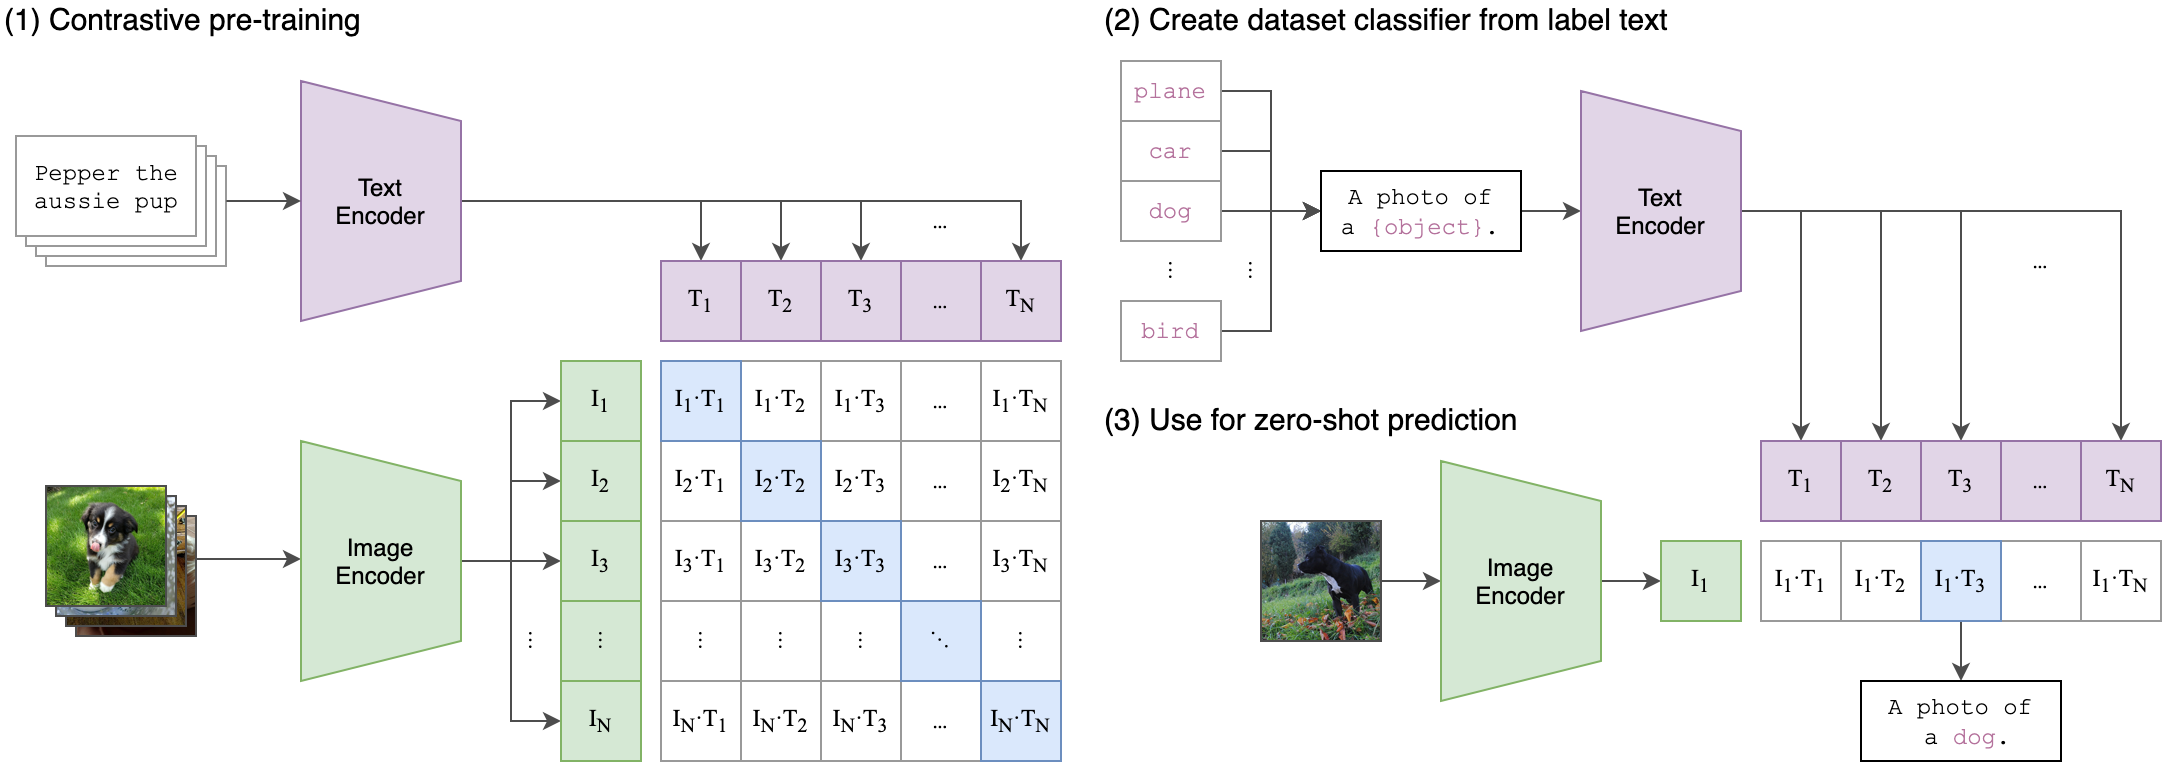

In [8]:
from IPython.display import display

# Open the downloaded image file
local_image = Image.open('CLIP.png')

# Display some information about the image (optional)
print(f"Image format: {local_image.format}")
print(f"Image size: {local_image.size}")

# You can also display it if you are in an environment that supports it (like a Jupyter Notebook)
display(local_image) # Uncomment this line to display the image

In [9]:
image = preprocess(local_image).unsqueeze(0).to(device)
text = clip.tokenize(["a diagram", "a dog", "a cat"]).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

    logits_per_image, logits_per_text = model(image, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

print("Label probs:", probs)  # prints: [[0.9927937  0.00421068 0.00299572]]

Label probs: [[0.9453   0.04855  0.005985]]


In [10]:
import numpy as np
# Tắt chế độ ký mã khoa học
np.set_printoptions(suppress=True)

probs = np.array([[5.1302550e-04, 9.9383622e-01, 5.6507424e-03]])
print(probs)
# Kết quả sẽ hiện: [[0.00051303  0.99383622  0.00565074]]

[[0.00051303 0.99383622 0.00565074]]


In [11]:
image_features.shape

torch.Size([1, 768])

In [12]:
text_features.shape

torch.Size([3, 768])

In [13]:
def get_clip_image_features(img_path):
    try:
        # 1. Đọc và tiền xử lý ảnh (dùng preprocess của CLIP)
        img = Image.open(img_path).convert('RGB')
        img_t = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            # 2. CHỈ lấy đặc trưng ảnh (Image Encoder)
            # Không cần tokenize text hay tính toán probs ở đây
            image_features = model.encode_image(img_t)

        # 3. Chuyển về numpy (đưa về CPU trước)
        return image_features.squeeze().cpu().numpy()
    except Exception as e:
        print(f"Lỗi xử lý CLIP cho {img_path}: {e}")
        return None

In [14]:
PATH = "/content/drive/MyDrive/Colab Notebooks/CTH001/AmazonData"

In [15]:
!ls "{PATH}/2014"

df_meta_5core_2014.parquet  image_feature.vgg16.b   ratings_Baby.csv
downloaded_images.zip	    meta_Baby.json.gz	    reviews_Baby_5.json.gz
image_feature.resnet50.b    ratings_Baby_5core.csv


In [16]:
!cp "{PATH}/2014/downloaded_images.zip" "downloaded_images.zip"

In [17]:
!unzip downloaded_images.zip

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: downloaded_images/B006ZOIT7Q.jpg  
  inflating: downloaded_images/B00ENUWX7G.jpg  
  inflating: downloaded_images/B0009F3OZE.jpg  
 extracting: downloaded_images/B004I8M5VC.jpg  
  inflating: downloaded_images/B00E8L0FZM.jpg  
  inflating: downloaded_images/B004L2JJAA.jpg  
  inflating: downloaded_images/B001NQMCQU.jpg  
 extracting: downloaded_images/B006GCAMG8.jpg  
  inflating: downloaded_images/B00C78CILM.jpg  
  inflating: downloaded_images/B000FCW15U.jpg  
  inflating: downloaded_images/B0062C5P4Q.jpg  
  inflating: downloaded_images/B000T9791K.jpg  
  inflating: downloaded_images/B003BHFP8Q.jpg  
  inflating: downloaded_images/B000067EH7.jpg  
  inflating: downloaded_images/B000BVKPNA.jpg  
  inflating: downloaded_images/B002DP57VW.jpg  
  inflating: downloaded_images/B0002XO5T2.jpg  
  inflating: downloaded_images/B0019CDXXE.jpg  
  inflating: downloaded_images/B00CASDZKC.jpg  
  inflating: downloaded_images/

### Tạo file `image_feature.b`

In [18]:
import os
import numpy as np
import array
from tqdm.notebook import tqdm # Import tqdm for progress bar

In [19]:
def read_image_features(path, feature_size):
    if not os.path.exists(path): return
    with open(path, 'rb') as f:
        while True:
            asin_bytes = f.read(10)
            if not asin_bytes: break
            try:
                asin = asin_bytes.decode('utf-8').strip()
                a = array.array('f')
                # Đọc đúng số lượng float bạn yêu cầu
                a.fromfile(f, feature_size)
                yield asin, a.tolist()
            except EOFError:
                break
            except Exception as e:
                print(f"Lỗi tại vị trí {f.tell()}: {e}")
                break

In [20]:
def extract_and_write_features(image_directory, output_file_path, existing_asins_set, feature_extractor_fn, expected_size):
    image_files = [f for f in os.listdir(image_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    total_images = len(image_files)
    processed_count = 0
    added_count = 0
    already_existing_count = 0
    invalid_asin_length_count = 0
    size_mismatch_count = 0 # Biến mới: Đếm lỗi sai kích thước vector

    print(f"Tìm thấy {total_images} hình ảnh. Đang trích xuất với size kỳ vọng: {expected_size}...")

    with open(output_file_path, 'ab') as f_out:
        for image_file in tqdm(image_files, desc="Trích xuất đặc trưng", unit="ảnh"):
            asin = os.path.splitext(image_file)[0].strip()
            img_path = os.path.join(image_directory, image_file)

            # 1. Check độ dài ASIN
            if len(asin) != 10:
                invalid_asin_length_count += 1
                processed_count += 1
                continue

            # 2. Check trùng
            if asin in existing_asins_set:
                already_existing_count += 1
                processed_count += 1
                continue

            # 3. Trích xuất
            features = feature_extractor_fn(img_path)

            if features is not None:
                try:
                    # Chuyển về numpy array 1D
                    features = np.array(features).flatten().astype(np.float32)

                    # KIỂM TRA ĐỘ DÀI TRƯỚC KHI GHI (Cực kỳ quan trọng)
                    if len(features) != expected_size:
                        size_mismatch_count += 1
                        processed_count += 1
                        continue

                    # Ghi ASIN (10 bytes)
                    f_out.write(asin[:10].encode('utf-8'))

                    # Ghi đúng số lượng float của model đó ra bytes
                    f_out.write(features.tobytes())

                    added_count += 1
                    existing_asins_set.add(asin)
                    f_out.flush() # Ghi ngay xuống đĩa
                except Exception as e:
                    print(f"Lỗi khi ghi ASIN '{asin}': {e}")
            else:
                print(f"Không trích xuất được ASIN '{asin}'.")

            processed_count += 1

    print("\n--- BÁO CÁO CHI TIẾT ---")
    print(f"Tổng số hình ảnh đã xử lý: {processed_count}")
    print(f"Số đặc trưng đã thêm mới: {added_count}")
    print(f"Số ASIN đã có sẵn (bỏ qua): {already_existing_count}")
    print(f"Số ASIN sai độ dài (không phải 10): {invalid_asin_length_count}")
    print(f"Số ảnh sai kích thước vector ({expected_size}): {size_mismatch_count}")

In [21]:
def main_feature_extraction(output_binary_file_name, image_directory, model_fn, feature_size):
    # 1. Load các ASIN cũ (Phải truyền đúng size của model đã dùng cho file đó)
    existing_asins = set()
    if os.path.exists(output_binary_file_name):
        print(f"Đang kiểm tra dữ liệu cũ (Size: {feature_size})...")
        for asin, _ in read_image_features(output_binary_file_name, feature_size):
            existing_asins.add(asin)

    # 2. Chạy trích xuất mới
    extract_and_write_features(image_directory, output_binary_file_name, existing_asins, model_fn, feature_size)

# --- VÍ DỤ SỬ DỤNG ---

# Nếu dùng VGG16:
# main_feature_extraction('vgg_features.b', 'download_image', get_vgg16_features, 4096)

# Nếu dùng ResNet50:
# main_feature_extraction('resnet_features.b', 'download_image', get_resnet_features, 2048)

In [22]:
# --- Script entry point ---
if __name__ == "__main__":
    output_binary_file = 'image_feature.b'
    image_dir = 'downloaded_images'
    main_feature_extraction(output_binary_file, image_dir, get_clip_image_features, 768)

Tìm thấy 7037 hình ảnh. Đang trích xuất với size kỳ vọng: 768...


Trích xuất đặc trưng:   0%|          | 0/7037 [00:00<?, ?ảnh/s]


--- BÁO CÁO CHI TIẾT ---
Tổng số hình ảnh đã xử lý: 7037
Số đặc trưng đã thêm mới: 7037
Số ASIN đã có sẵn (bỏ qua): 0
Số ASIN sai độ dài (không phải 10): 0
Số ảnh sai kích thước vector (768): 0


In [24]:
!cp "/content/image_feature.b" "{PATH}/2014/image_feature.open_ai_clip.b"

### Kiểm tra file vừa tạo bằng hàm `readImageFeatures` của bạn

In [28]:
import array

# Đọc và kiểm tra file 'image_feature.b' vừa tạo
print(f"\nKiểm tra nội dung file '{output_binary_file}' bằng hàm của bạn:")
count = 0
for asin, features in read_image_features(output_binary_file, 768):
    print(f"ASIN: {asin}, Kiểu dữ liệu: {type(features)}, Kích thước: {len(features)}")
    if count < 2: # Chỉ in chi tiết 3 mục đầu để không quá dài
        print(f"  Một vài giá trị đầu tiên: {features[:5]}")
    count += 1
    if count >= 3: # Giới hạn số lượng mục in ra
        print("... và nhiều mục khác.")
        break

print(f"Tổng số mục đã đọc: {count}")



Kiểm tra nội dung file 'image_feature.b' bằng hàm của bạn:
ASIN: B004LE8ZYO, Kiểu dữ liệu: <class 'list'>, Kích thước: 768
  Một vài giá trị đầu tiên: [0.1322021484375, 0.280029296875, 0.058135986328125, 1.0732421875, 0.1688232421875]
ASIN: B0080HPWMG, Kiểu dữ liệu: <class 'list'>, Kích thước: 768
  Một vài giá trị đầu tiên: [0.53857421875, 0.78076171875, -0.002696990966796875, -0.261474609375, 0.5263671875]
ASIN: B008RJ9BH4, Kiểu dữ liệu: <class 'list'>, Kích thước: 768
... và nhiều mục khác.
Tổng số mục đã đọc: 3
